In [37]:
import matplotlib
#import seaborn as sns
#sns.set_context("paper")
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
plt.style.use('seaborn-v0_8-colorblind')
#matplotlib.rc("font", family="Times New Roman")
# Global font settings
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 12,            # Base font size
    "axes.titlesize": 18,      # Title
    "axes.labelsize": 12,       # X and Y labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 9,
})

In [59]:
df = pd.read_csv("L.csv")
print(df.head())
# Define 4 base colors (one for each pair)
base_colors = ['#1f77b4',  '#ff7f0e','#2ca02c', '#d62728']  # Blue, Orange,Green, Red
# Lighter variants for the '-IR' versions
light_colors = ['#aec7e8', '#ffbb78','#98df8a',  '#f28e8c']

     SGD-DA       SGD  SGD-L2-DA    SGD-L2  SGD-DA-IR    SGD-IR  SGD-L2-DA-IR  \
0  4.242511  4.146678   3.970392  3.865342   4.373119  4.541178      4.438867   
1  3.685984  3.512436   3.650987  3.474306   4.212629  4.386321      4.222055   
2  3.699224  2.984828   3.365155  2.918278   4.059525  4.175453      4.082905   
3  2.982509  2.882522   3.785795  2.950120   3.964962  4.053920      4.127213   
4  2.559996  2.505368   2.602174  2.733625   3.767209  3.921227      3.852312   

   SGD-L2-IR  
0   4.569055  
1   4.352844  
2   4.171167  
3   4.113994  
4   3.863943  


/var/folders/dy/p06tnkrj5gx6y73ndgxp5xdc0000gq/T/ipykernel_62142/283217070.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


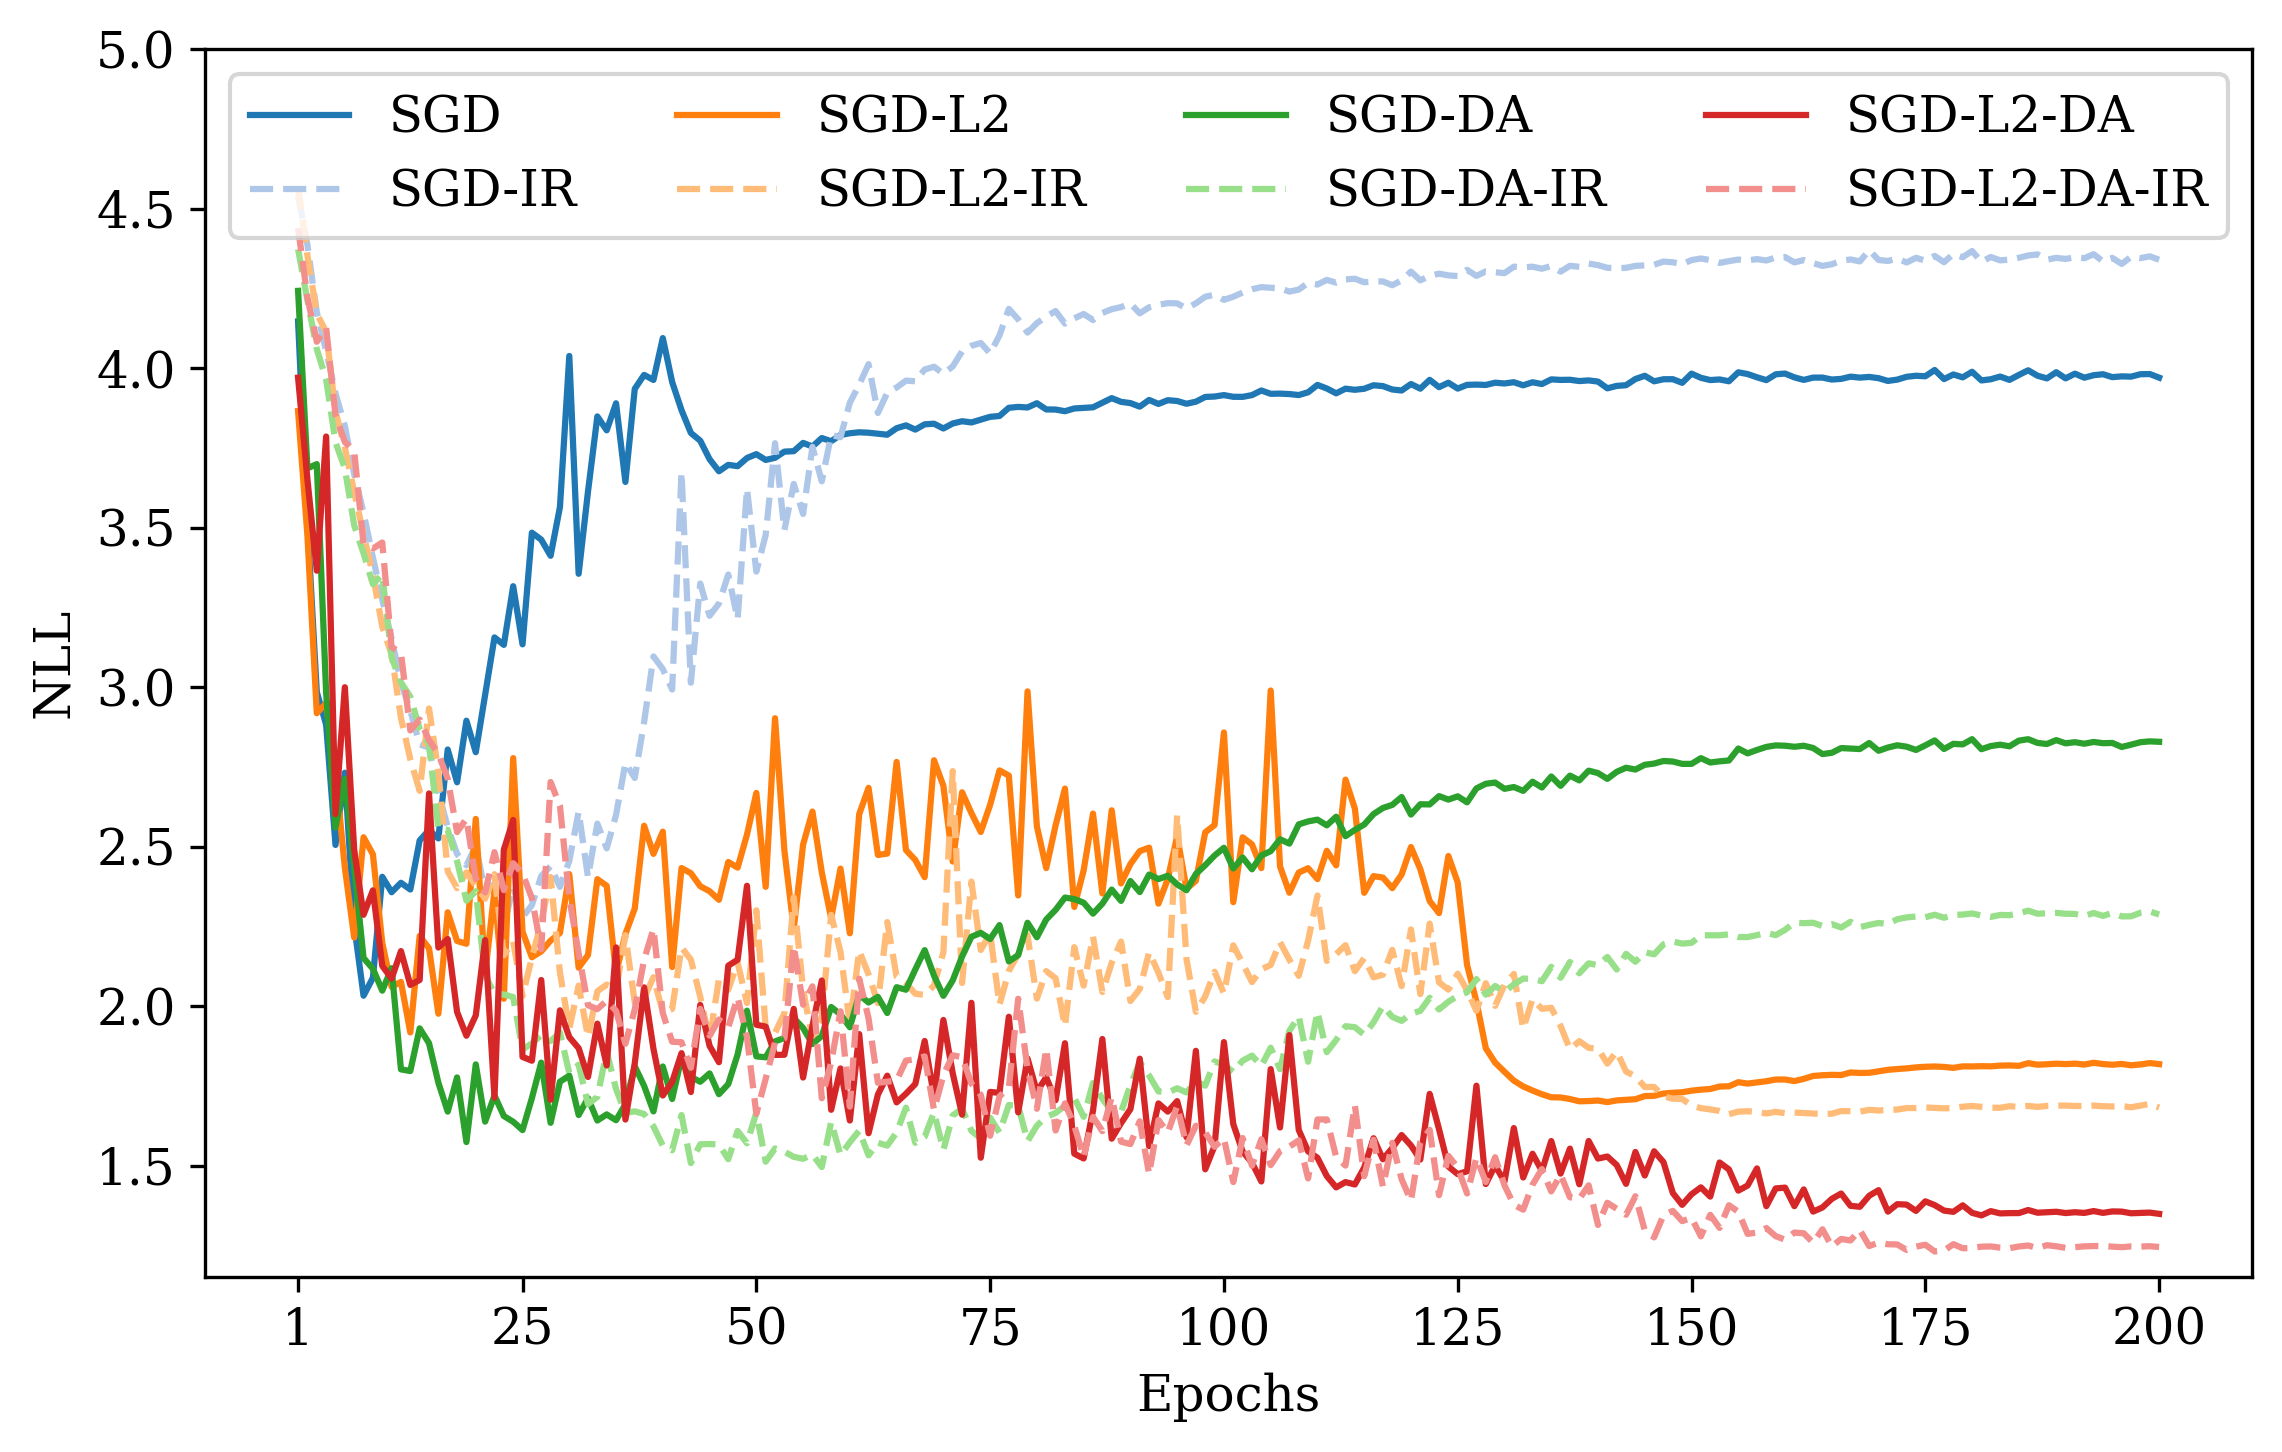

In [60]:
columns = ['SGD','SGD-L2','SGD-DA','SGD-L2-DA']

fig, ax = plt.subplots(dpi=300,figsize=(8, 5), tight_layout=True)
for indx, column in enumerate(columns):
    ax.plot(df.index + 1, df[column], label=column,color=base_colors[indx])
    column_pair = column + '-IR'
    ax.plot(df.index + 1, df[column_pair], label=column_pair,color=light_colors[indx],linestyle='--')
    xticks = list(range(0, 200 + 1, 25))
    xticks[0] = 1
    ax.set_xticks(xticks)

    ax.tick_params(axis='x', labelrotation = 0)
    ax.set(xlabel='Epochs', ylabel='NLL')
    ax.legend(loc='upper left', ncol=4, fontsize=11.95)
    #ax.set_title('ticks')
    ax.set_ylim(1.15, 5.0)
fig.show()

In [61]:
fig.savefig('ablation_nll.pdf',bbox_inches='tight',dpi=600)

### following code is the repeat for the above to plot alphaD, only difference is adjust the postion of legend according to the plot visually

     SGD-DA       SGD  SGD-L2-DA    SGD-L2  SGD-DA-IR    SGD-IR  SGD-L2-DA-IR  \
0  0.870600  0.978220   0.700191  0.800894   0.071644  0.023686      0.050879   
1  1.053616  1.088313   0.969296  1.217959   0.126119  0.072764      0.114547   
2  1.484234  1.073962   1.280042  1.106692   0.154391  0.160315      0.166098   
3  1.184522  1.226811   1.698477  1.178115   0.189547  0.170459      0.195483   
4  1.071723  1.115705   1.147704  1.203431   0.254324  0.216997      0.223241   

   SGD-L2-IR  
0   0.018672  
1   0.099522  
2   0.130931  
3   0.149885  
4   0.214884  


/var/folders/dy/p06tnkrj5gx6y73ndgxp5xdc0000gq/T/ipykernel_62142/1692346992.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


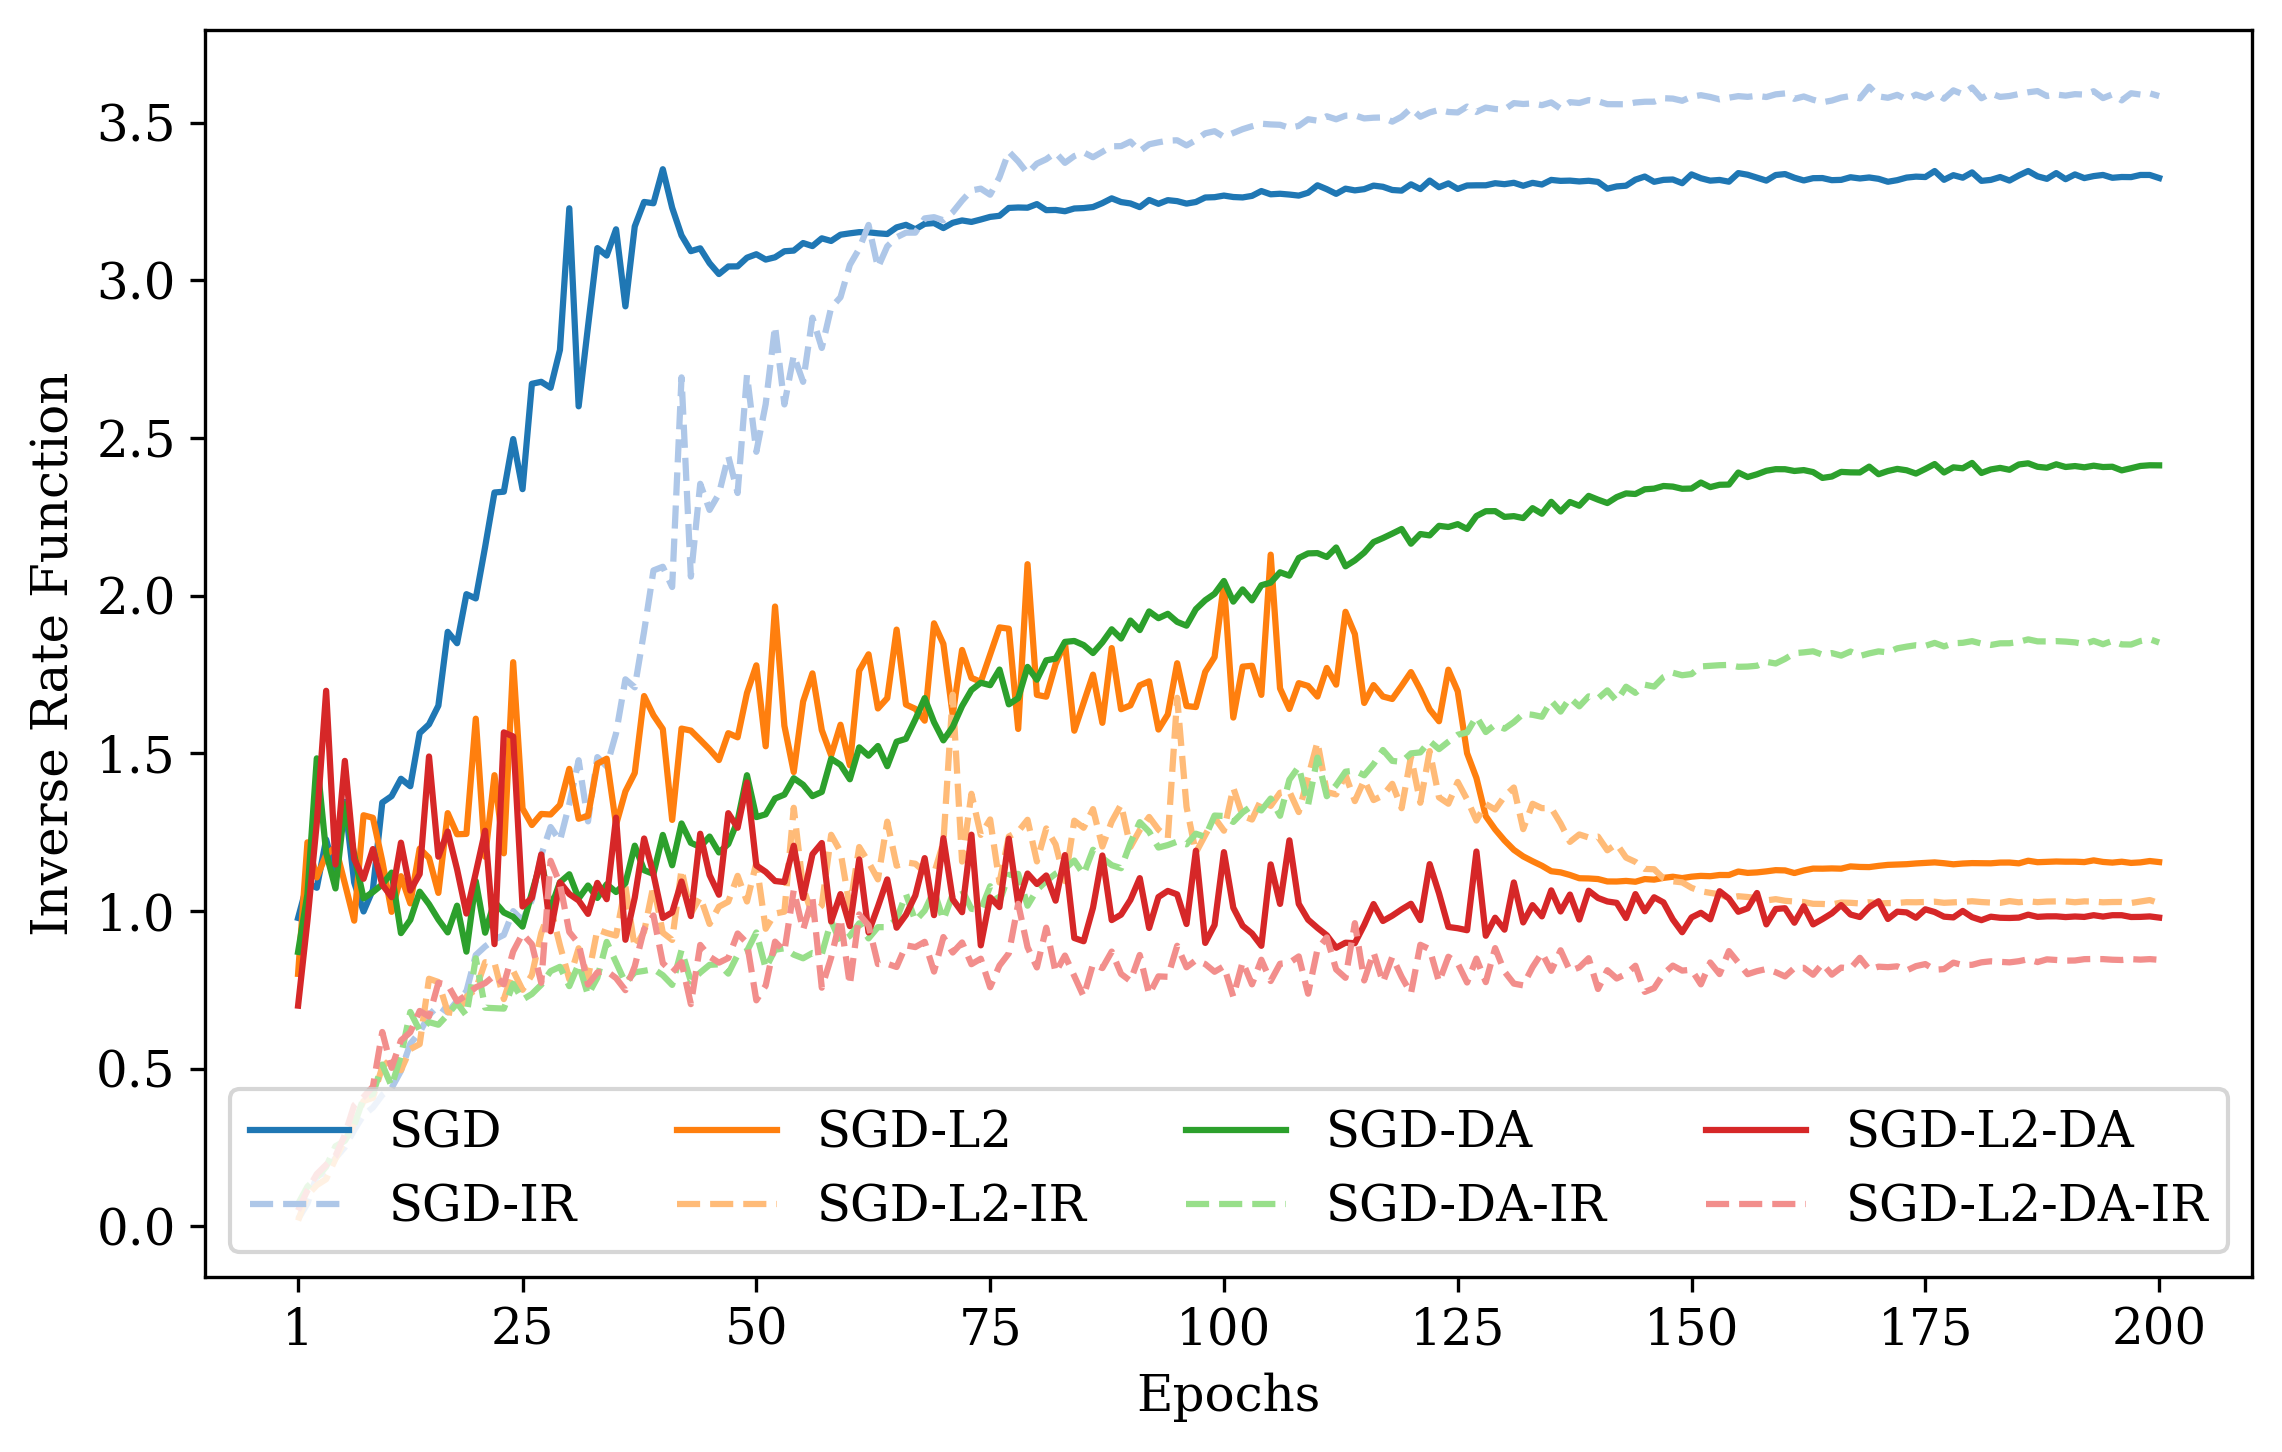

In [62]:
df = pd.read_csv("alphaD.csv")
print(df.head())
# Define 4 base colors for without reg
base_colors = ['#1f77b4',  '#ff7f0e','#2ca02c', '#d62728']  # Blue, Orange,Green, Red
# Lighter variants for the '-IR' versions
light_colors = ['#aec7e8', '#ffbb78','#98df8a',  '#f28e8c']
columns = ['SGD','SGD-L2','SGD-DA','SGD-L2-DA']
fig, ax = plt.subplots(dpi=300,figsize=(8, 5), tight_layout=True)
for indx, column in enumerate(columns):
    ax.plot(df.index + 1, df[column], label=column,color=base_colors[indx])
    column_pair = column + '-IR'
    ax.plot(df.index + 1, df[column_pair], label=column_pair,color=light_colors[indx],linestyle='--')
    xticks = list(range(0, 200 + 1, 25))
    xticks[0] = 1
    ax.set_xticks(xticks)
    ax.tick_params(axis='x', labelrotation = 0)
    ax.set(xlabel='Epochs', ylabel='Inverse Rate Function')
    ax.legend(
    loc='best',         # anchor point on the legend box
    #bbox_to_anchor=(0.2, 0.85), # (x, y) in axis coordinates
    #borderaxespad=0.,
    ncol=4,
    fontsize=11.95
)
    #ax.set_title('ticks')

fig.show()



In [63]:
fig.savefig('ablation_ir.pdf',bbox_inches='tight',dpi=600)